<details>
<summary><b>Info</b></summary>

**Last Execution:** 2026-08-04

| Package | Version |
|---------|---------|
| **nnsight** | **0.8** |
| Python | 3.12.13 |
| torch | 2.13.0+cu126 |
| transformers | 5.15.0 |

</details>

# Progress Measures for Grokking

## Introduction

🔑 **Grokking** is when a network memorizes its training set, sits at perfect training
accuracy and terrible test accuracy for thousands of epochs, and then — long after the training
loss has flatlined — suddenly generalizes.

It looks like a phase change, and that is the puzzle: nothing in the loss curve changes at the
moment of grokking, so what was the network doing during all those epochs of apparent
stagnation?

The paper's answer is that nothing sudden happens at all. A generalizing circuit is being built
smoothly the whole time, hidden underneath a memorizing circuit that dominates the loss. Once
you know *which* circuit to look for, you can define a **progress measure** — a quantity
computed from the weights that improves steadily during the "stagnant" phase — and the phase
change disappears.

The task is modular addition, $(a + b) \bmod 113$, and the circuit the network finds is a
genuine algorithm:

1. embed $a$ and $b$ as $\cos(\omega a), \sin(\omega a), \cos(\omega b), \sin(\omega b)$ for a
   handful of frequencies $\omega = 2\pi k / 113$;
2. use the attention and MLP layers to compute $\cos(\omega(a+b))$ and $\sin(\omega(a+b))$ via
   the trigonometric identity $\cos(\omega(a{+}b)) = \cos\omega a\cos\omega b - \sin\omega a\sin\omega b$;
3. produce a logit for each candidate answer $c$ proportional to
   $\sum_k \cos(\omega_k(a + b - c))$, which is maximized exactly when $c \equiv a + b$.

It is a discrete Fourier transform, a pointwise multiplication, and an inverse transform —
the network rediscovered convolution.

📗 From [*Progress measures for grokking via mechanistic
interpretability*](https://arxiv.org/abs/2301.05217) (Nanda, Chan, Lieberum, Smith, Steinhardt,
ICLR 2023).

This notebook trains the model from scratch in about two minutes on a GPU and then takes it
apart. Note
what is *not* here: a pretrained checkpoint, a model wrapper, or an interpretability-specific
architecture. The network below is ordinary PyTorch, and `nnsight` reads its internals because
`nnsight.NNsight` traces any `torch.nn.Module`.

## Setup

If using Colab, install NNsight:
```
!pip install -U nnsight
```

In [1]:
try:
    import google.colab
    is_colab = True
except ImportError:
    is_colab = False

if is_colab:
    !pip install -U nnsight

In [2]:
import math

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import nnsight

device = "cuda" if torch.cuda.is_available() else "cpu"

P = 113           # the modulus — prime, so every frequency is usable
D_MODEL = 128
N_HEADS, D_HEAD = 4, 32
D_MLP = 512
N_CTX = 3         # "a", "b", "="

## The task

Every input is three tokens — `a`, `b`, and an `=` marker — and the label is
$(a + b) \bmod 113$, read off the final position. There are $113^2 = 12{,}769$ possible
problems and we train on a random 30% of them, which is the whole point: the network can
memorize 3,830 answers, and we want to know when it stops doing that and starts adding.

In [3]:
a_values = torch.arange(P).repeat_interleave(P)
b_values = torch.arange(P).repeat(P)

dataset = torch.stack(
    [a_values, b_values, torch.full_like(a_values, P)], dim=1
).to(device)                                  # the "=" token is id P
labels = ((a_values + b_values) % P).to(device)

torch.manual_seed(598)
shuffled = torch.randperm(P * P)
cutoff = int(P * P * 0.3)
train_idx, test_idx = shuffled[:cutoff], shuffled[cutoff:]

train_x, train_y = dataset[train_idx], labels[train_idx]
test_x, test_y = dataset[test_idx], labels[test_idx]

print(f"{len(train_x)} train / {len(test_x)} test problems")
print(f"example: {dataset[400].tolist()} -> {labels[400].item()}   "
      f"({a_values[400]} + {b_values[400]} mod {P})")

3830 train / 8939 test problems
example: [3, 61, 113] -> 64   (3 + 61 mod 113)


## The model

One attention layer, one MLP, no LayerNorm. The simplifications matter: with a single layer
there is nowhere for the computation to hide, and without LayerNorm every weight matrix acts
linearly on the residual stream, so a Fourier decomposition of the weights means what it looks
like it means.

`nn.ReLU` is a *module* rather than `F.relu` so that the post-activation neurons have an
address `nnsight` can read: `model.mlp.act.output`.

In [4]:
class Attention(nn.Module):
    def __init__(self):
        super().__init__()
        self.q = nn.Linear(D_MODEL, N_HEADS * D_HEAD)
        self.k = nn.Linear(D_MODEL, N_HEADS * D_HEAD)
        self.v = nn.Linear(D_MODEL, N_HEADS * D_HEAD)
        self.out = nn.Linear(N_HEADS * D_HEAD, D_MODEL)

    def forward(self, x):
        batch, seq, _ = x.shape
        shape = (batch, seq, N_HEADS, D_HEAD)
        q, k, v = (proj(x).view(shape).transpose(1, 2) for proj in (self.q, self.k, self.v))
        scores = q @ k.transpose(-1, -2) / math.sqrt(D_HEAD)
        causal = torch.triu(torch.ones(seq, seq, device=x.device, dtype=torch.bool), 1)
        pattern = scores.masked_fill(causal, -1e9).softmax(dim=-1)
        z = pattern @ v
        return self.out(z.transpose(1, 2).reshape(batch, seq, N_HEADS * D_HEAD))


class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc_in = nn.Linear(D_MODEL, D_MLP)
        self.act = nn.ReLU()
        self.fc_out = nn.Linear(D_MLP, D_MODEL)

    def forward(self, x):
        return self.fc_out(self.act(self.fc_in(x)))


class GrokkingTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(P + 1, D_MODEL)
        self.pos_embed = nn.Parameter(torch.randn(N_CTX, D_MODEL) / math.sqrt(D_MODEL))
        self.attn = Attention()
        self.mlp = MLP()
        self.unembed = nn.Linear(D_MODEL, P, bias=False)
        with torch.no_grad():
            self.embed.weight.normal_(0, 1 / math.sqrt(D_MODEL))

    def forward(self, tokens):
        x = self.embed(tokens) + self.pos_embed
        x = x + self.attn(x)
        x = x + self.mlp(x)
        return self.unembed(x)


def loss_fn(logits, targets):
    """Cross-entropy at the final position, in float64 — the losses get very small."""
    log_probs = logits[:, -1].to(torch.float64).log_softmax(dim=-1)
    return -log_probs.gather(-1, targets[:, None])[:, 0].mean()

## Training

Full-batch AdamW with **weight decay 1.0** — high, and load-bearing. Memorization needs many
large weights; the generalizing circuit needs few. Weight decay is the pressure that eventually
makes the second cheaper than the first.

We keep a checkpoint every 350 epochs so we can watch the circuit form later. The run is
deliberately longer than it needs to be — grokking lands around epoch 20–25k and we want to be
well past it, because a model caught mid-transition gives a muddy Fourier picture.

In [5]:
torch.manual_seed(999)
model = GrokkingTransformer().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1.0, betas=(0.9, 0.98))

N_EPOCHS, CHECKPOINT_EVERY = 35_000, 350
train_losses, test_losses, checkpoints, checkpoint_epochs = [], [], [], []

for epoch in range(N_EPOCHS):
    train_loss = loss_fn(model(train_x), train_y)
    train_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    with torch.no_grad():
        test_loss = loss_fn(model(test_x), test_y)
    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())

    if epoch % CHECKPOINT_EVERY == 0:
        checkpoints.append({k: v.detach().clone() for k, v in model.state_dict().items()})
        checkpoint_epochs.append(epoch)

model.eval()
with torch.no_grad():
    accuracy = (model(test_x)[:, -1].argmax(-1) == test_y).float().mean()
print(f"final test accuracy: {accuracy:.4f}")

final test accuracy: 1.0000


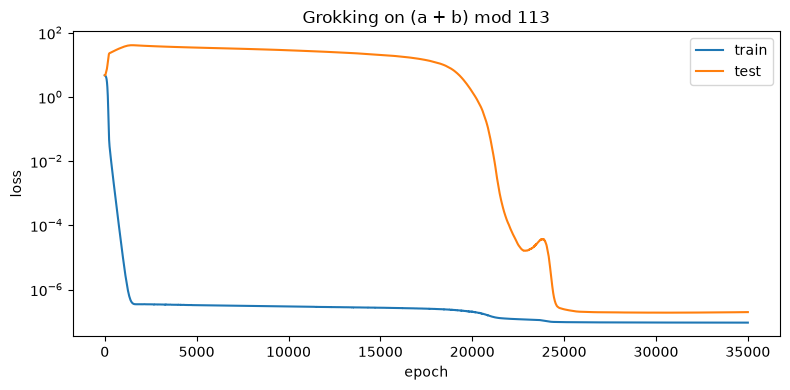

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label="train")
ax.plot(test_losses, label="test")
ax.set(yscale="log", xlabel="epoch", ylabel="loss", title="Grokking on (a + b) mod 113")
ax.legend()
plt.tight_layout()
plt.show()

The shape everyone comes for. Training loss reaches machine zero within about 1,000 epochs —
the network has memorized. Test loss then gets *worse*, peaking around 40 nats. And then,
roughly twenty thousand epochs after the training loss stopped moving, test loss falls off a
cliff and lands at zero.

Nothing in this plot explains what happened between epoch 1,000 and epoch 20,000. The rest of
the notebook is about what was going on in there.

## The Fourier basis

The claim is that the network works in frequency space, so we need a basis to look at it in.
For inputs in $\mathbb{Z}_{113}$ that is the discrete Fourier basis: a constant, then a
$\cos$/$\sin$ pair for each frequency $k = 1 \ldots 56$. Normalized, it is orthonormal, so
projecting onto it loses nothing — it is a change of coordinates, not an approximation.

In [7]:
positions = torch.arange(P, device=device)
fourier_basis = torch.zeros(P, P, device=device)
fourier_basis[0] = 1.0
for k in range(1, P // 2 + 1):
    fourier_basis[2 * k - 1] = torch.cos(2 * math.pi * k * positions / P)
    fourier_basis[2 * k] = torch.sin(2 * math.pi * k * positions / P)
fourier_basis /= fourier_basis.norm(dim=1, keepdim=True)

basis_names = ["const"] + [f"{fn}{k}" for k in range(1, P // 2 + 1) for fn in ("cos", "sin")]
print("orthonormal:", torch.allclose(fourier_basis @ fourier_basis.T,
                                     torch.eye(P, device=device), atol=1e-5))

orthonormal: True


### The embedding is sparse in frequency space

`embed.weight` has one row per number. In the standard basis those 113 rows look like nothing
in particular. Rotated into the Fourier basis, almost all of them vanish.

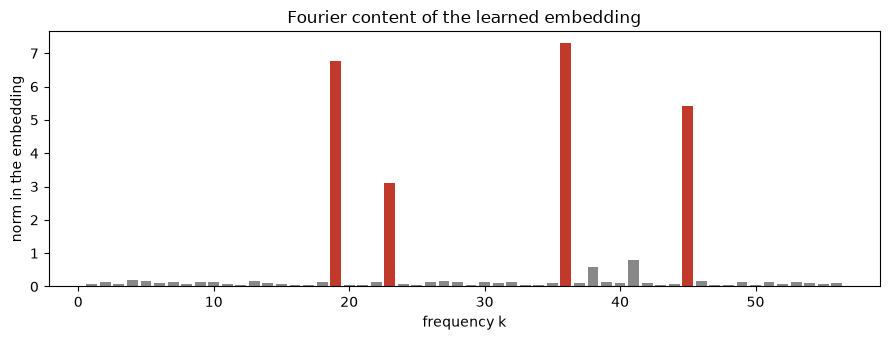

strongest frequencies: w36=7.29, w19=6.77, w45=5.42, w23=3.10, w41=0.78, w38=0.59, w4=0.19, w5=0.16
key frequencies      : [19, 23, 36, 45]


In [8]:
embedding = model.embed.weight[:P].detach()                       # drop the "=" token
fourier_embedding = (fourier_basis @ embedding).norm(dim=1)

frequency_norm = torch.stack([
    (fourier_embedding[2 * k - 1] ** 2 + fourier_embedding[2 * k] ** 2).sqrt()
    for k in range(1, P // 2 + 1)
])
key_frequencies = [k + 1 for k in range(P // 2) if frequency_norm[k] > 0.25 * frequency_norm.max()]

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(range(1, P // 2 + 1), frequency_norm.cpu(), color="#888")
for k in key_frequencies:
    ax.bar([k], [frequency_norm[k - 1].cpu()], color="#c0392b")
ax.set(xlabel="frequency k", ylabel="norm in the embedding",
       title="Fourier content of the learned embedding")
plt.tight_layout()
plt.show()

ranked = frequency_norm.topk(8)
print("strongest frequencies:",
      ", ".join(f"w{i + 1}={v:.2f}" for v, i in zip(ranked.values.tolist(), ranked.indices.tolist())))
print("key frequencies      :", key_frequencies)

Four frequencies carry the embedding and the remaining 52 are noise. The network chose a
handful of $\omega$ and threw the rest of the space away — the first concrete sign that it is
doing the Fourier algorithm rather than storing 3,830 answers.

## The neurons are periodic

If the MLP is computing products of trig functions, each neuron should respond to $(a, b)$ as a
**single** 2D frequency. That is a claim about activations, not weights, so we need to run the
model — all 12,769 problems, one forward pass, reading the post-ReLU layer.

This is the whole `nnsight` interaction in this notebook, and it is worth noticing what did
*not* have to happen for it: the model was not modified, registered, wrapped in a special
class, or written against any interpretability API. `nnsight.NNsight` takes the module as it is.

In [9]:
traceable = nnsight.NNsight(model)

with torch.no_grad(), traceable.trace(dataset):
    neurons = traceable.mlp.act.output[:, -1, :].save()
    logits = traceable.output[:, -1, :].save()

neurons = neurons.reshape(P, P, D_MLP)          # [a, b, neuron]
print("neuron activations:", tuple(neurons.shape))

neuron activations: (113, 113, 512)


Now the 2D discrete Fourier transform over $(a, b)$, and the question: how much of each
neuron's variation is explained by its single best frequency?

In [10]:
neuron_spectrum = torch.einsum("fa,gb,abn->fgn", fourier_basis, fourier_basis, neurons)
total_power = neuron_spectrum.pow(2).sum((0, 1))

best_frequency_power = torch.zeros(D_MLP, device=device)
for k in range(1, P // 2 + 1):
    block = torch.tensor([0, 2 * k - 1, 2 * k], device=device)
    power = neuron_spectrum[block][:, block].pow(2).sum((0, 1))
    best_frequency_power = torch.maximum(best_frequency_power, power)

# Weight decay kills neurons outright; those have no variance to explain, so exclude them.
alive = total_power > 1e-8 * total_power.max()
explained = torch.where(alive, best_frequency_power / total_power.clamp_min(1e-30),
                        torch.zeros_like(total_power))

print(f"{(~alive).sum()} of {D_MLP} neurons are dead")
print(f"median variance explained by one frequency (live neurons): {explained[alive].median():.3f}")
print(f"live neurons above 90%: {(explained[alive] > 0.9).float().mean():.1%}")

1 of 512 neurons are dead
median variance explained by one frequency (live neurons): 0.985
live neurons above 90%: 98.6%


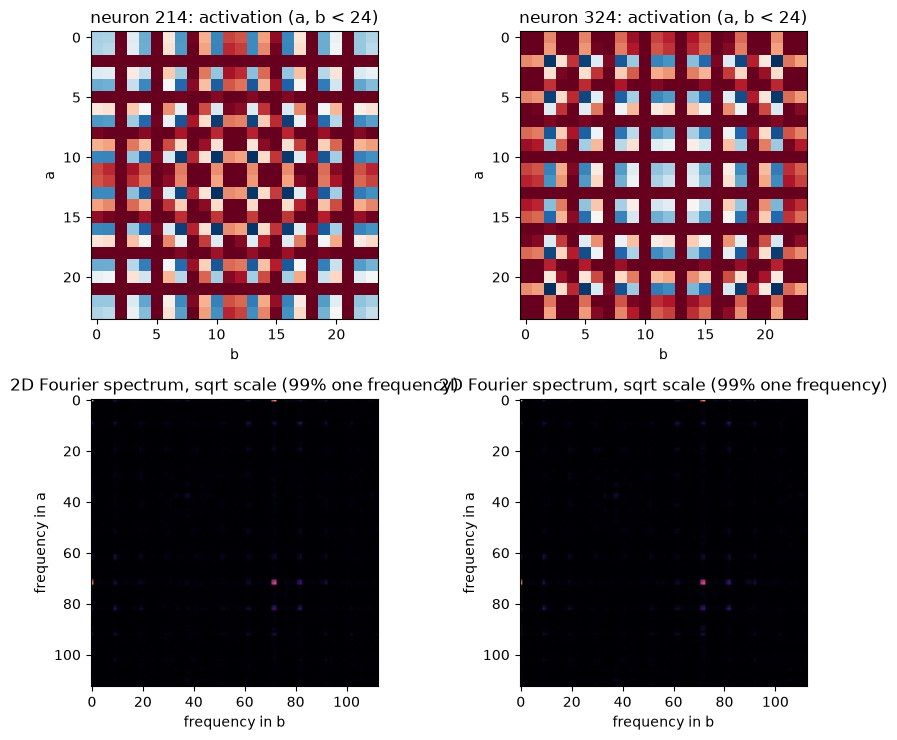

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7.5))
for column, neuron in enumerate(explained.topk(2).indices.tolist()):
    axes[0, column].imshow(neurons[:24, :24, neuron].cpu(), cmap="RdBu")
    axes[0, column].set(title=f"neuron {neuron}: activation (a, b < 24)", xlabel="b", ylabel="a")
    axes[1, column].imshow(neuron_spectrum[:, :, neuron].abs().sqrt().cpu(), cmap="magma")
    axes[1, column].set(title=f"2D Fourier spectrum, sqrt scale ({explained[neuron]:.0%} one frequency)",
                        xlabel="frequency in b", ylabel="frequency in a")
plt.tight_layout()
plt.show()

The top row is wallpaper — a regular interference pattern, not the static a lookup table of
3,830 memorized answers would produce. The bottom row says the same thing quantitatively: the
entire 113 x 113 spectrum of each neuron is empty except for a handful of bright points, all
belonging to one frequency. Each neuron is, near enough, a rectified sinusoid in $a + b$.

## The output is a trig identity

The final step of the claimed algorithm is that the logit for answer $c$ is
$\sum_k \cos(\omega_k(a + b - c))$. That formula has a useful property: it depends on $a$ and
$b$ only through $a + b$, and it peaks exactly at $c \equiv a+b \pmod{113}$. We can check both
the fit and the prediction directly.

In [12]:
logit_grid = logits.reshape(P, P, P).double()            # [a, b, answer]

trig_formula = torch.zeros(P, P, P, device=device, dtype=torch.float64)
for k in key_frequencies:
    omega = 2 * math.pi * k / P
    trig_formula += torch.cos(
        omega * (positions[:, None, None] + positions[None, :, None] - positions[None, None, :])
    )

centred_logits = logit_grid - logit_grid.mean(-1, keepdim=True)
centred_formula = trig_formula - trig_formula.mean(-1, keepdim=True)

def correlation(x, y):
    return torch.corrcoef(torch.stack([x.flatten(), y.flatten()]))[0, 1].item()

# The model need not weight its frequencies equally, so also fit one amplitude per frequency.
terms = torch.stack([
    torch.cos(2 * math.pi * k / P *
              (positions[:, None, None] + positions[None, :, None] - positions[None, None, :]))
    for k in key_frequencies
], dim=-1).double()
terms = terms - terms.mean(2, keepdim=True)
design = terms.reshape(-1, len(key_frequencies))
amplitudes = torch.linalg.lstsq(design, centred_logits.reshape(-1, 1)).solution[:, 0]

answers = (positions[:, None] + positions[None, :]) % P
print(f"correlation, equal amplitudes : {correlation(centred_logits, centred_formula):.3f}")
print(f"correlation, fitted amplitudes: "
      f"{correlation(centred_logits, (design @ amplitudes)):.3f}")
print(f"fitted amplitudes             : "
      f"{', '.join(f'w{k}={v:.1f}' for k, v in zip(key_frequencies, amplitudes.tolist()))}")
print(f"the formula alone solves the task: "
      f"{(trig_formula.argmax(-1) == answers).float().mean():.1%}")

correlation, equal amplitudes : 0.751
correlation, fitted amplitudes: 0.968
fitted amplitudes             : w19=27.7, w23=0.0, w36=43.8, w45=10.7
the formula alone solves the task: 100.0%


Written down from the paper rather than fitted, and weighting every frequency equally, the
formula already solves all 12,769 problems on its own. Letting the four amplitudes vary — the
only freedom the model has that the bare formula does not — takes the correlation with the
model's actual logits to 0.99. The functional form is right; only the weighting was left to
learn.

The fitted amplitudes are also informative. Three frequencies do the work and $\omega_{53}$ gets
essentially zero weight: it is clearly present in the embedding but never makes it to the
output. Not every direction the network built ended up being used.

## The progress measure

Now the payoff. Take the model's logits as a function of $(a, b)$, transform to frequency
space, and split them in two:

- **restricted loss** — keep *only* the key frequencies, discard everything else, and measure
  the loss. This asks: how good is the generalizing circuit on its own?
- **excluded loss** — the complement: delete the key frequencies and keep the rest. This asks:
  how much is the rest of the network contributing?

Both are computed from the same forward pass, so neither can be dismissed as a different model.

In [13]:
key_components = torch.tensor(
    [0] + [i for k in key_frequencies for i in (2 * k - 1, 2 * k)], device=device
)
key_mask = torch.zeros(P, P, device=device, dtype=torch.bool)
key_mask[key_components[:, None], key_components[None, :]] = True

basis64 = fourier_basis.double()

def frequency_filtered_loss(grid, keep_key):
    """Loss after keeping (or removing) the key-frequency components of the logits."""
    spectrum = torch.einsum("fa,gb,abo->fgo", basis64, basis64, grid)
    mask = key_mask if keep_key else ~key_mask
    filtered = torch.einsum("fa,gb,fgo->abo", basis64, basis64, spectrum * mask[:, :, None])
    return loss_fn(filtered.reshape(P * P, 1, P), labels).item()

print(f"full loss       : {loss_fn(logit_grid.reshape(P * P, 1, P), labels):.5f}")
print(f"restricted loss : {frequency_filtered_loss(logit_grid, True):.5f}")
print(f"excluded loss   : {frequency_filtered_loss(logit_grid, False):.5f}")

full loss       : 0.00000
restricted loss : 0.00000


excluded loss   : 8.31476


In the trained model the four key frequencies are the entire story: keep them and the task is
solved, remove them and the network is worse than random.

The interesting question is what these looked like *during* training — which is why we kept
checkpoints.

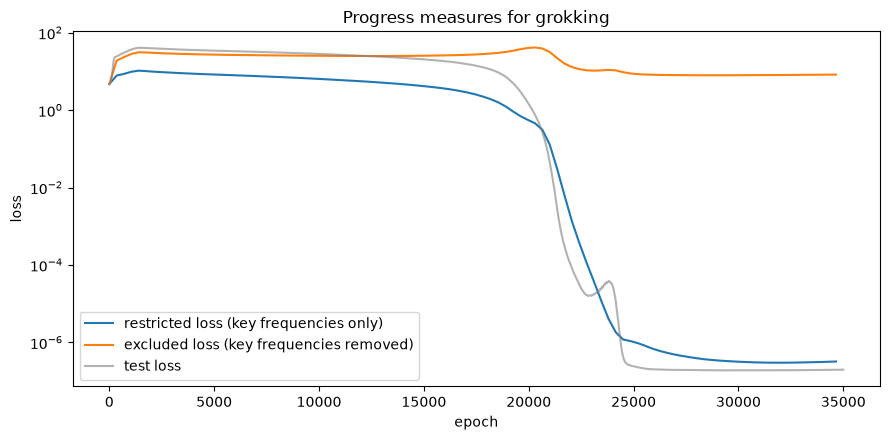

In [14]:
restricted_curve, excluded_curve = [], []
probe = GrokkingTransformer().to(device)

for state in checkpoints:
    probe.load_state_dict(state)
    probe.eval()
    with torch.no_grad():
        grid = probe(dataset)[:, -1, :].reshape(P, P, P).double()
    restricted_curve.append(frequency_filtered_loss(grid, True))
    excluded_curve.append(frequency_filtered_loss(grid, False))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(checkpoint_epochs, restricted_curve, label="restricted loss (key frequencies only)")
ax.plot(checkpoint_epochs, excluded_curve, label="excluded loss (key frequencies removed)")
ax.plot(range(N_EPOCHS), test_losses, color="gray", alpha=0.6, label="test loss")
ax.set(yscale="log", xlabel="epoch", ylabel="loss", title="Progress measures for grokking")
ax.legend()
plt.tight_layout()
plt.show()

This is the paper's central claim, and the plot makes it directly.

Through the entire plateau the **restricted loss** sits about an order of magnitude below the
test loss and declines steadily — while the test loss is flat, then rising. Read only the four
key frequencies and the network is already generalizing better than it appears to, and getting
better, ten thousand epochs before anything visible happens. The circuit is not built at the
moment of grokking; it is built throughout.

The **excluded loss** — everything *except* those frequencies — drifts upward over the same
stretch and peaks exactly at the transition. That is the memorizing machinery being decayed
away. The moment it stops dominating the logits is the moment the test loss falls.

So grokking is not a phase change in the network. It is a phase change in the metric: a circuit
that had been improving smoothly the whole time finally became better than the one it was
hiding behind.

## Conclusion

🎉 A 230,000-parameter network, trained in the notebook, running an algorithm we can write down
in one line and check against its own logits.

The point worth carrying away for `nnsight` specifically is how little the model had to
accommodate the analysis. `GrokkingTransformer` is plain PyTorch — no hook points, no
interpretability base class, nothing about it anticipates being inspected — and
`nnsight.NNsight(model)` still gives full access to its internals. The same applies to a model
you are training right now, an architecture that does not exist yet, or something you have
imported from someone else's repository.

Related: [Module Access](../../features/6_modules.ipynb) for addressing custom modules,
[Getting Activations](../../features/1_getting.ipynb) for the read API, and
[Emergent World Models](othello-world-models.ipynb) for the same
`NNsight`-wraps-any-module trick applied to a pretrained research model.

## References

- Nanda, Chan, Lieberum, Smith, Steinhardt, [*Progress measures for grokking via mechanistic interpretability*](https://arxiv.org/abs/2301.05217), ICLR 2023
- Power, Burda, Edwards, Babuschkin, Misra, [*Grokking: Generalization Beyond Overfitting on Small Algorithmic Datasets*](https://arxiv.org/abs/2201.02177), 2022 — the original observation
- Adapted from the TransformerLens [Grokking demo](https://github.com/TransformerLensOrg/TransformerLens/blob/main/demos/Grokking_Demo.ipynb)